In [1]:
!hpc-ticket
!hpc-mount wissdaten

## Standard epidataloader

In [5]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, NodeRFModel, ClimateologyModel

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2010-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

(<Figure size 1600x1700 with 3 Axes>,
 array([<Axes: title={'center': 'SK Hamburg [node: 15]'}, ylabel='target'>,
        <Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>,
        <Axes: title={'center': 'LK Hildburghausen [node: 391]'}, ylabel='target'>],
       dtype=object))

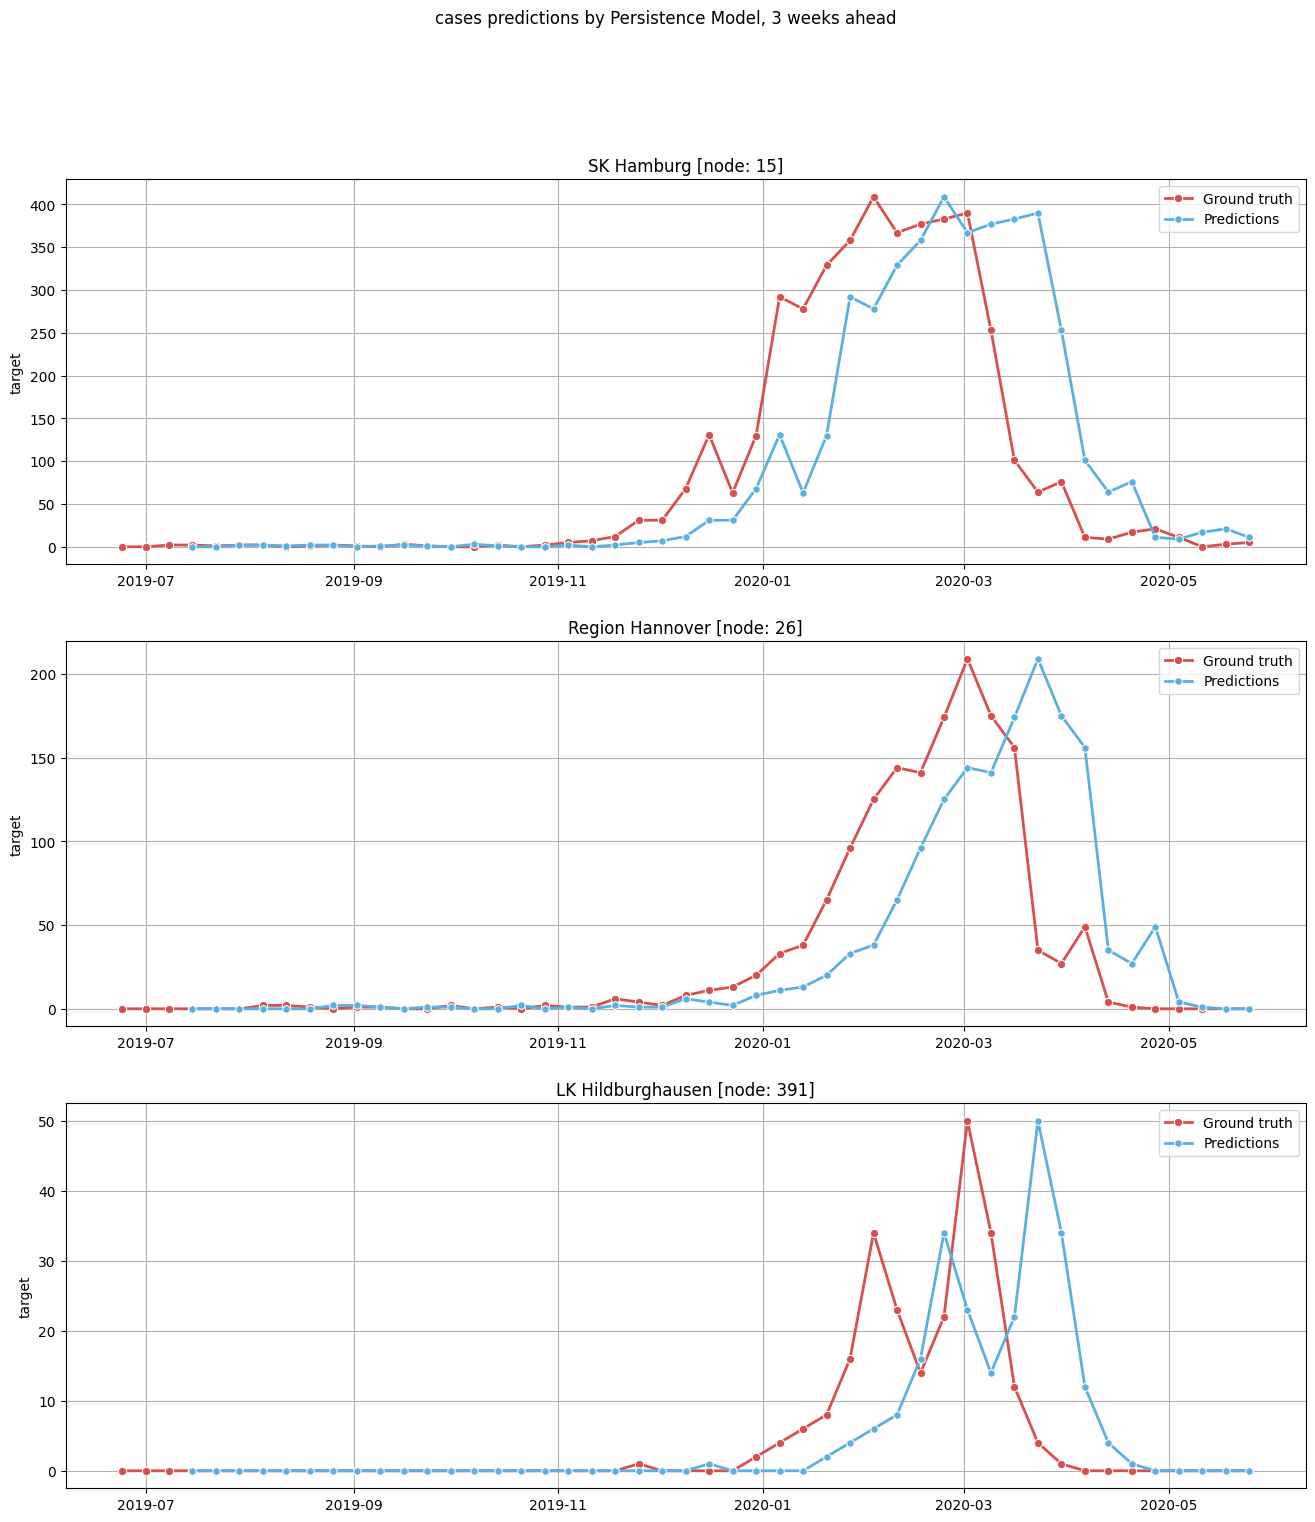

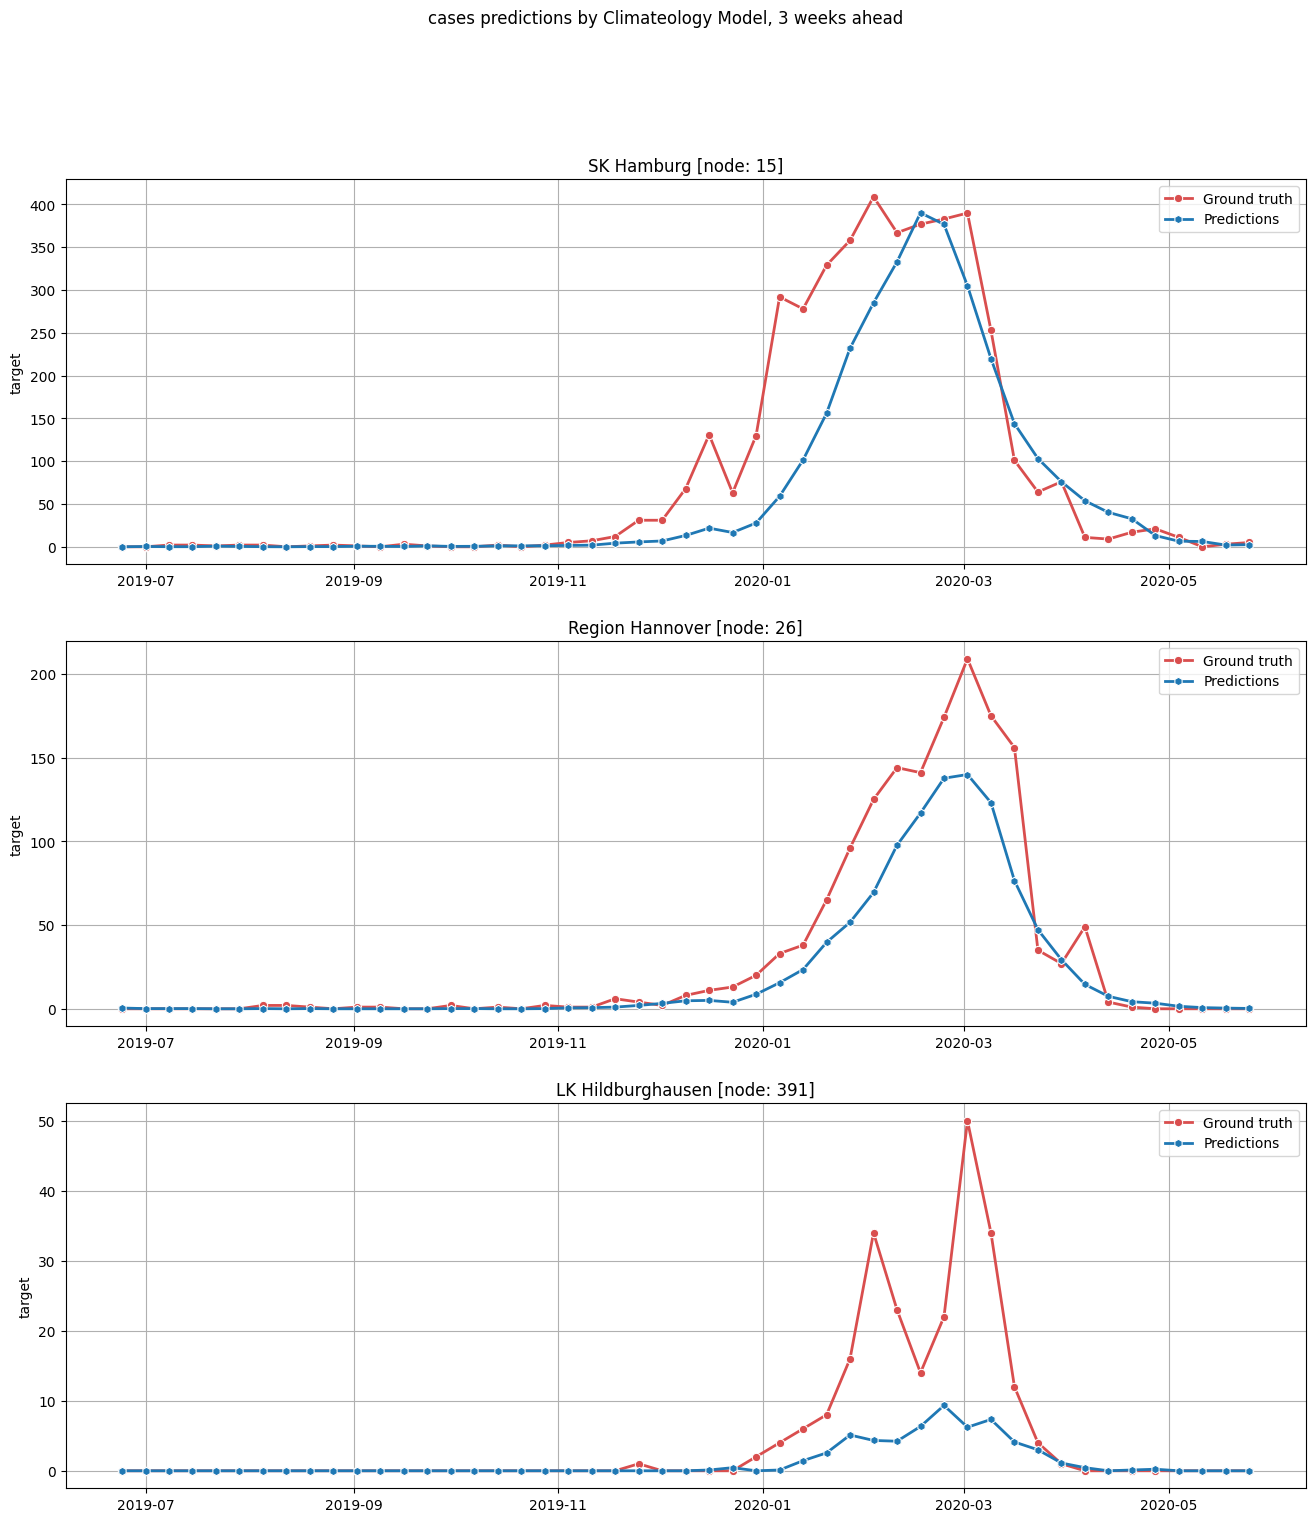

In [6]:
sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
ps.show_forecasts([15, 26, 391], 'test')

cm.forecast('test')
cm.show_forecasts([15, 26, 391], 'test')

(<Figure size 1600x700 with 1 Axes>,
 [<Axes: title={'center': 'LK Hildburghausen [node: 391]'}, ylabel='target'>])

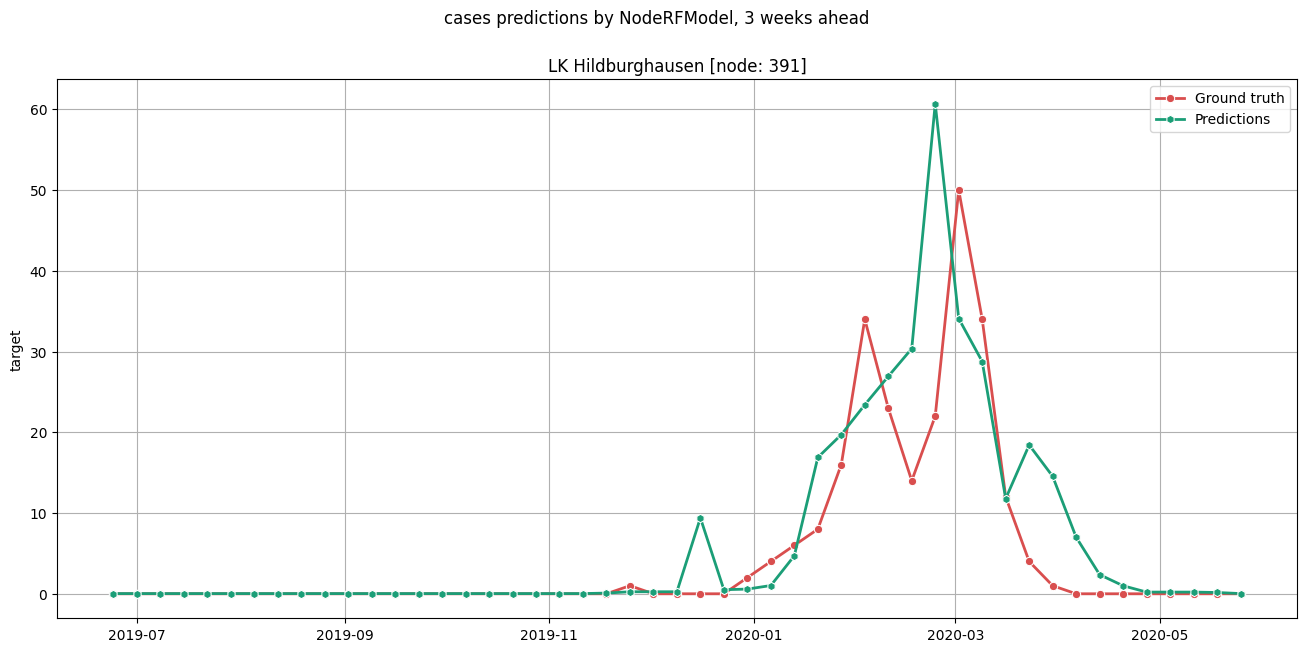

In [7]:
rf = NodeRFModel(sl)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=27)
rf.train(verbose=0)
rf.forecast('test')
rf.show_forecasts(391,'test')